# 03 · Features, split temporal e modelos

**Previsão de atraso de entrega no e-commerce brasileiro (Olist)** · Notebook 3 de 3

Este notebook cobre a etapa de modelagem: as duas features históricas do vendedor (construção hermética anti-vazamento, o ponto técnico central do projeto), o split temporal com corte medido por volumetria, e a comparação de três modelos. **Regra de ouro desta etapa: o conjunto de TESTE não é tocado aqui.** Toda seleção (hiperparâmetros, modelo campeão e, na próxima etapa, threshold) usa um bloco de validação temporal DENTRO do treino; o teste será usado uma única vez, na avaliação final.

O código reutilizável vive em `src/features.py` (construção das features, com os porquês em docstring) e `src/train.py` (split, pipelines e grades de modelos). Aqui o notebook narra e executa.

In [1]:
import json
import subprocess
import warnings

warnings.filterwarnings("ignore", message="X does not have valid feature names")
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.features import build_seller_history_features
from src.train import (
    CATEGORICAL_FEATURES,
    FEATURES,
    NUMERIC_FEATURES,
    TARGET,
    build_model_grid,
    describe_params,
    evaluate,
    temporal_split,
)

master = pd.read_parquet(ROOT / "data" / "processed" / "master_table.parquet")
items = pd.read_csv(ROOT / "data" / "raw" / "olist_order_items_dataset.csv")
print(f"tabela mestra: {len(master):,} pedidos · taxa {master[TARGET].mean():.2%}")
print(f"features na whitelist: {len(FEATURES)} ({len(NUMERIC_FEATURES)} numéricas + {len(CATEGORICAL_FEATURES)} categóricas)")

tabela mestra: 96,470 pedidos · taxa 6.77%
features na whitelist: 21 (18 numéricas + 3 categóricas)


## 1. As features históricas do vendedor (construção hermética)

A EDA mostrou que o passado do vendedor separa personas (gargalos com 16,5% de atraso e postagem de 7,4 dias). Para transformar isso em previsão por pedido, duas features resumem o histórico de cada vendedor **no instante exato de cada compra**: a taxa de atraso passada e o tempo médio de postagem passado.

**Por que o `shift(1)` clássico não basta.** A receita padrão (ordenar por compra e deslocar uma linha) tem um furo: o desfecho do pedido anterior só passa a existir quando ele é **entregue**, ~10 dias depois da compra. Um pedido comprado 2 dias após o anterior usaria, no treino, uma informação que ninguém tinha naquele instante. Em produção, a feature store não teria esse valor, e o modelo veria uma feature mais informativa no treino do que na vida real.

**A construção adotada: cada informação entra no histórico no instante em que nasce.**

- O **desfecho** (atrasou ou não) fica disponível na data de **entrega ao cliente**;
- O **tempo de postagem** fica disponível na data de **entrega à transportadora** (relógio mais cedo: a postagem é observável antes do desfecho).

Para o pedido comprado em $t$, contam apenas eventos com disponibilidade estritamente anterior a $t$. Implementação vetorizada: por vendedor, eventos ordenados por disponibilidade com soma acumulada + busca binária ($O(n \log n)$; detalhes em `src/features.py`).

**Cold start:** vendedor sem entrega anterior recebe a média GLOBAL histórica (mesma regra hermética, todos os vendedores) + flag `seller_no_history`. No comecinho do dataset nem o global existe: fica NaN, tratado pelo imputador de mediana treinado só no treino. **Multi-vendedor:** máximo entre os vendedores do pedido (elo mais fraco), lendo TODOS os vendedores, não só o principal.

O contrato anti-vazamento desta feature é **executável**: 6 testes pytest em `tests/test_features.py` cobrem os casos críticos, incluindo "o desfecho é invisível antes da entrega" e "o relógio da postagem corre antes do relógio do desfecho".

In [2]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", str(ROOT / "tests"), "-q"],
    capture_output=True, text=True, cwd=ROOT,
)
print(result.stdout.strip().splitlines()[-1])
assert result.returncode == 0, "testes da feature crítica falharam"

6 passed in 0.67s


In [3]:
hist = build_seller_history_features(master, items)
master = master.merge(hist, on="order_id", how="left")

print(f"pedidos com flag seller_no_history: {master['seller_no_history'].mean():.2%}")
print(f"NaN residual (início do dataset, sem histórico nem global): {master['seller_late_rate_hist'].isna().sum()}")
print("\nmédia da feature por classe do alvo:")
print(master.groupby(TARGET)[["seller_late_rate_hist", "seller_posting_days_hist"]].mean().round(4).to_string())

pedidos com flag seller_no_history: 5.50%
NaN residual (início do dataset, sem histórico nem global): 266

média da feature por classe do alvo:
         seller_late_rate_hist  seller_posting_days_hist
is_late                                                 
0                       0.0437                    3.1633
1                       0.0493                    3.4958


A separação univariada é modesta (pedidos que atrasaram vêm de vendedores com histórico pior, 4,9% vs 4,4%, e postagem passada mais lenta), o que é esperado: a feature trabalha em conjunto com distância, janela e mês, e sua contribuição real será medida na importância de features da etapa de avaliação.

## 2. Split temporal com corte medido (e um conflito de volumetria resolvido)

Decisões já tomadas: teste truncado em **2018-09-01** (a cobertura de entregas zera em setembro, viés de sobrevivência medido no notebook 01) e aspiração de ~80/20 com corte perto de março/2018, mantendo a greve dos caminhoneiros (maio/2018) dentro do teste.

A volumetria real revela que **as duas aspirações são incompatíveis**: como o volume cresce ao longo do tempo, o ponto que deixaria 80% dos pedidos no treino cai no FIM de maio de 2018, o que colocaria a greve no treino e reduziria o teste ao regime recalibrado pós-greve, destruindo a âncora narrativa do split. Entre a fração e a âncora, fica a âncora: **corte em 2018-03-01**, com split real de ~59/41. Trade-off aceito e documentado: menos treino (modelos um pouco piores), mais teste (métricas mais estáveis), e um teste que contém a saída da crise de fev–mar, a greve de maio e a recalibração de junho, exatamente os regimes que a produção enfrentaria.

In [4]:
TEST_END = "2018-09-01"
CUT = "2018-03-01"
VAL_START = "2018-01-01"

pop = master[master["order_purchase_timestamp"] < pd.Timestamp(TEST_END)].copy()
q80 = pop["order_purchase_timestamp"].quantile(0.8)
print(f"quantil 80% das compras: {q80:%Y-%m-%d} (incompatível com a greve no teste)")

rows = []
for cut in ("2018-03-01", "2018-04-01", "2018-06-01"):
    tr, te = temporal_split(pop, cut, TEST_END)
    rows.append({
        "corte": cut,
        "treino": len(tr), "treino_%": round(100 * len(tr) / len(pop), 1),
        "taxa_treino_%": round(100 * tr[TARGET].mean(), 2),
        "teste": len(te), "taxa_teste_%": round(100 * te[TARGET].mean(), 2),
        "greve_no_teste": cut <= "2018-05-01",
    })
pd.DataFrame(rows).set_index("corte")

quantil 80% das compras: 2018-05-26 (incompatível com a greve no teste)


,treino,treino_%,taxa_treino_%,teste,taxa_teste_%,greve_no_teste
corte,,,,,,
2018-03-01,57317,59.4,6.60,39153,7.02,True
2018-04-01,64320,66.7,7.95,32150,4.42,True
2018-06-01,77867,80.7,7.53,18603,3.61,False


In [5]:
train, test = temporal_split(pop, CUT, TEST_END)
core, val = temporal_split(train, VAL_START, CUT)

print(f"treino: {len(train):,} pedidos até {CUT} (taxa {train[TARGET].mean():.2%})")
print(f"  ├─ núcleo de treino: {len(core):,} até {VAL_START} (taxa {core[TARGET].mean():.2%})")
print(f"  └─ validação temporal: {len(val):,} de jan–fev/2018 (taxa {val[TARGET].mean():.2%})")
print(f"teste (INTOCADO nesta etapa): {len(test):,} de {CUT} a {TEST_END} (taxa {test[TARGET].mean():.2%})")

treino: 57,317 pedidos até 2018-03-01 (taxa 6.60%)
  ├─ núcleo de treino: 43,693 até 2018-01-01 (taxa 5.62%)
  └─ validação temporal: 13,624 de jan–fev/2018 (taxa 9.75%)
teste (INTOCADO nesta etapa): 39,153 de 2018-03-01 a 2018-09-01 (taxa 7.02%)


Nota sobre o bloco de validação: jan–fev/2018 é justamente a **crise logística** vista na EDA (taxa de 9,8% contra 5,6% do núcleo). Hiperparâmetros e threshold serão escolhidos, portanto, sob estresse de mudança de regime, uma escolha conservadora e realista: é exatamente o tipo de deslocamento que o modelo enfrentará no teste e em produção.

## 3. Três modelos, um pipeline, seleção na validação

Cada candidato é um pipeline sklearn único: imputação de mediana **aprendida só no fold de treino** (fecha a decisão da etapa 2 de não imputar na tabela mestra), one-hot para UF/categoria/tipo de pagamento, e o classificador. Desbalanceamento por pesos de classe (`class_weight`/`scale_pos_weight`), nunca reamostragem sintética: preserva a distribuição real e deixa a decisão de custo para o threshold, onde ela pertence ao negócio.

Grade pequena e manual (11 ajustes no total), critério de seleção **AUC-PR na validação** (classe positiva rara torna a área sob precision-recall mais informativa que a ROC).

In [6]:
X_core, y_core = core[FEATURES], core[TARGET]
X_val, y_val = val[FEATURES], val[TARGET]
scale_pos_weight = float((y_core == 0).sum() / (y_core == 1).sum())

results = []
fitted = {}
for family, grid in build_model_grid(scale_pos_weight).items():
    for pipe in grid:
        pipe.fit(X_core, y_core)
        metrics = evaluate(pipe, X_val, y_val)
        results.append({"família": family, "hiperparâmetros": describe_params(pipe), **metrics})
        fitted[(family, describe_params(pipe))] = pipe

results = pd.DataFrame(results)
best = results.loc[results.groupby("família")["auc_pr"].idxmax()]
results.sort_values("auc_pr", ascending=False).round(4).reset_index(drop=True)

,família,hiperparâmetros,auc_pr,auc_roc
0,Regressão Logística,C=0.1,0.2282,0.7165
1,Regressão Logística,C=1.0,0.2227,0.7117
2,Regressão Logística,C=10.0,0.2190,0.7102
3,Random Forest,"depth=8, leaf=20",0.1924,0.6882
4,LightGBM,"n=300, leaves=15",0.1919,0.6784
5,Random Forest,"depth=12, leaf=20",0.1890,0.6839
6,Random Forest,"depth=16, leaf=5",0.1887,0.6788
7,Random Forest,"depth=None, leaf=20",0.1852,0.6766
8,LightGBM,"n=300, leaves=31",0.1849,0.6661
9,LightGBM,"n=600, leaves=31",0.1774,0.6490


In [7]:
best.sort_values("auc_pr", ascending=False).round(4).set_index("família")

,hiperparâmetros,auc_pr,auc_roc
família,,,
Regressão Logística,C=0.1,0.2282,0.7165
Random Forest,"depth=8, leaf=20",0.1924,0.6882
LightGBM,"n=300, leaves=15",0.1919,0.6784


**Leitura honesta do resultado: o baseline vence.** A Regressão Logística (C=0,1, a mais regularizada da grade) supera Random Forest e LightGBM em AUC-PR na validação, e dentro de cada família de árvores as configurações MAIS simples são as melhores (LightGBM prefere 15 folhas a 63; a floresta prefere profundidade 8). Tudo aponta o mesmo mecanismo: entre o núcleo de treino (2016–2017, taxa 5,6%) e a validação (crise de jan–fev/2018, taxa 9,8%) há uma mudança de regime, e modelos de maior capacidade memorizam padrões específicos do regime antigo que não se transferem; o modelo linear, mais rígido, carrega estrutura global (distância, janela, histórico do vendedor) que sobrevive à mudança.

Não é um resultado constrangedor, é um resultado informativo: **complexidade extra não comprou desempenho neste problema com este split honesto**. Com split aleatório (que mistura futuro no treino), as árvores provavelmente venceriam, e essa vitória seria uma ilusão de vazamento temporal. Os três finalistas (o melhor de cada família) seguem para a avaliação única no teste, na próxima etapa.

## 4. Teste de sanidade: o alvo embaralhado

Prova executável do contrato anti-vazamento: treinando o melhor LightGBM com o alvo **permutado aleatoriamente**, nenhuma feature pode conter informação sobre esse alvo falso, e a AUC-ROC na validação deve cair para ~0,5 (moeda ao ar). Se ficasse alta, alguma coluna estaria entregando a resposta por construção.

In [8]:
rng = np.random.default_rng(42)
y_shuffled = pd.Series(rng.permutation(y_core.to_numpy()), index=y_core.index)

best_lgbm_params = best.loc[best["família"] == "LightGBM", "hiperparâmetros"].iloc[0]
sanity_pipe = [
    p for p in build_model_grid(scale_pos_weight)["LightGBM"]
    if describe_params(p) == best_lgbm_params
][0]
sanity_pipe.fit(X_core, y_shuffled)
auc_shuffled = evaluate(sanity_pipe, X_val, y_val)["auc_roc"]
print(f"AUC-ROC com alvo embaralhado: {auc_shuffled:.3f} (esperado ≈ 0,5)")
assert 0.45 < auc_shuffled < 0.55, "possível vazamento estrutural"

AUC-ROC com alvo embaralhado: 0.500 (esperado ≈ 0,5)


## 5. Finalistas reajustados no treino completo e persistidos

Escolhidos os hiperparâmetros na validação, cada finalista é reajustado no **treino inteiro** (núcleo + validação, até o corte) para aproveitar todos os dados disponíveis, e persistido para a etapa de avaliação, onde o teste será tocado uma única vez.

In [9]:
import joblib

MODELS_DIR = ROOT / "data" / "processed" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

X_train, y_train = train[FEATURES], train[TARGET]
for _, row in best.iterrows():
    pipe = fitted[(row["família"], row["hiperparâmetros"])]
    pipe.fit(X_train, y_train)
    slug = row["família"].lower().replace(" ", "_").replace("ã", "a").replace("í", "i")
    joblib.dump(pipe, MODELS_DIR / f"{slug}.joblib")
    print(f"salvo: {slug}.joblib ({row['hiperparâmetros']})")

split_config = {"cut": CUT, "test_end": TEST_END, "val_start": VAL_START}
(MODELS_DIR / "split_config.json").write_text(json.dumps(split_config))
print("split_config.json salvo:", split_config)

salvo: lightgbm.joblib (n=300, leaves=15)


salvo: random_forest.joblib (depth=8, leaf=20)


salvo: regressao_logistica.joblib (C=0.1)
split_config.json salvo: {'cut': '2018-03-01', 'test_end': '2018-09-01', 'val_start': '2018-01-01'}


## 6. Conclusões da etapa e handoff

1. **Features históricas herméticas construídas e testadas:** cada informação entra no instante em que nasce (desfecho na entrega, postagem no despacho); 6 testes pytest verdes cobrem o contrato, incluindo o caso que o `shift(1)` clássico erraria.
2. **Split temporal fixado por volumetria com trade-off explícito:** corte 2018-03-01 (59/41), âncora narrativa preservada (crise, greve e recalibração dentro do teste), teste truncado em 2018-09-01.
3. **Três modelos comparados na validação temporal:** o baseline linear vence sob mudança de regime; complexidade extra não comprou desempenho com split honesto.
4. **Sanidade verificada:** alvo embaralhado derruba a AUC para ~0,5.
5. **Teste ainda intocado.** Próxima etapa: avaliação única no teste com estratificação mensal (crise → greve → recalibração), escolha de threshold na validação, cenário de negócio em contagens e importância de features.

## 7. Avaliação final: o teste aberto uma única vez

A partir daqui começa a etapa de avaliação, com três disciplinas declaradas ANTES de qualquer número:

1. **O campeão já foi escolhido na validação** (Regressão Logística C=0,1) e não muda, qualquer que seja o resultado do teste. O teste REPORTA; quem escolhe usando o teste transforma o teste em treino.
2. **O ponto de operação é um ORÇAMENTO DE ALERTAS, não um threshold de probabilidade.** Motivo medido neste projeto: a escala de probabilidades desloca quando o modelo é reajustado no treino completo (o retreino incluiu a crise de jan–fev, elevando as probabilidades previstas), então um corte como "0,38" escolhido no modelo do núcleo não transfere para o modelo final. Já "notificar os k% pedidos de maior risco" transfere entre retreinos e é como uma operação real planeja capacidade. Cada ponto da curva precision-recall corresponde a um orçamento; o orçamento é escolhido na VALIDAÇÃO (fora da amostra, com o modelo do núcleo) e apenas aplicado ao teste. Calibração de probabilidades fica registrada como próximo passo natural.
3. Todos os menus e importâncias usam a validação; o teste aparece uma única vez, nas tabelas marcadas como teste.

In [10]:
import joblib
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.metrics import precision_recall_curve

from src.evaluate import (
    business_scenario,
    final_comparison,
    monthly_stratification,
    pick_operating_points,
    threshold_for_alert_rate,
)

ACCENT, GRAY, INK = "#2a78d6", "#898781", "#0b0b0b"
plt.rcParams.update(
    {
        "figure.figsize": (9, 3.8),
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "grid.color": "#e1e0d9",
        "grid.linewidth": 0.8,
        "axes.edgecolor": GRAY,
        "axes.labelcolor": "#52514e",
        "xtick.color": GRAY,
        "ytick.color": GRAY,
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titleweight": "bold",
    }
)

CHAMPION = "Regressão Logística"
BEST_PARAMS = {row["família"]: row["hiperparâmetros"] for _, row in best.iterrows()}

# Core-fitted copies of the finalists: the out-of-sample lens on validation,
# used for every CHOICE (operating points, importance). The full-train refits
# (in `fitted`) are used only for the single test pass.
core_fitted, ops_by_model = {}, {}
for family, grid in build_model_grid(scale_pos_weight).items():
    pipe = [p for p in grid if describe_params(p) == BEST_PARAMS[family]][0]
    pipe.fit(X_core, y_core)
    core_fitted[family] = pipe
    ops_by_model[family] = pick_operating_points(
        y_val, pipe.predict_proba(X_val)[:, 1]
    )

ops = ops_by_model[CHAMPION]
ops.round(4)

,beta,threshold,precisão_val,recall_val,alert_rate_val
ponto,,,,,
conservador,0.5,0.4838,0.3126,0.2009,0.0627
equilibrado,1.0,0.3793,0.2503,0.4146,0.1616
agressivo,2.0,0.2466,0.1643,0.7043,0.4182


O menu da campeã tem três pontos nomeados, escolhidos por máximos de F-beta (critério objetivo, sem cortes arbitrários): **conservador** (F0,5, precisão pesa dobrado), **equilibrado** (F1, o default do projeto) e **agressivo** (F2, recall pesa dobrado). A coluna `alert_rate_val` é o orçamento de alertas de cada ponto.

In [11]:
finalists = {
    row["família"]: fitted[(row["família"], row["hiperparâmetros"])]
    for _, row in best.iterrows()
}
alert_rates = {
    fam: float(ops_by_model[fam].loc["equilibrado", "alert_rate_val"])
    for fam in finalists
}
X_test, y_test = test[FEATURES], test[TARGET]

comparison = final_comparison(finalists, alert_rates, X_test, y_test)
comparison.round(4)

,auc_pr_teste,auc_roc_teste,orçamento_alertas,precisão_teste,recall_teste,f1_teste
modelo,,,,,,
LightGBM,0.1807,0.7420,0.2389,0.1614,0.5493,0.2495
Random Forest,0.1371,0.6641,0.2237,0.1363,0.4343,0.2075
Regressão Logística,0.1375,0.6989,0.1616,0.1574,0.3623,0.2195


**Leitura honesta da única passada no teste: o LightGBM venceu no teste (AUC-PR 0,181 e AUC-ROC 0,742), e a campeã continua sendo a Regressão Logística.** As duas frases convivem, e explicar por quê é o ponto mais maduro do projeto:

- **Por que não trocamos:** o protocolo fixou a seleção na validação. Trocar de modelo DEPOIS de ver o teste é usar o teste para selecionar, exatamente o vício que o protocolo existe para impedir; a métrica reportada da troca seria inflada pela própria escolha (maldição do vencedor).
- **Por que os dois resultados divergem:** a validação é UMA janela (jan–fev/2018, regime de crise), e seleção em janela única tem variância. No regime da crise, a rigidez do linear venceu; nos seis meses do teste (saída da crise, greve, recalibração), a capacidade extra do LightGBM voltou a pagar. Nenhum vazamento, nenhuma contradição: amostras diferentes, respostas diferentes.
- **O que isso ensina para produção:** seleção de modelo mais robusta exige validação em MÚLTIPLAS janelas temporais (rolling origin), registrada como próximo passo. Com uma janela só, o protocolo honesto entrega o que prometeu: uma estimativa não inflada, e a documentação transparente da incerteza de seleção.

Referência de leitura das AUC-PR do teste contra o acaso (prevalência 7,02%): campeã 0,138 = 2,0x o acaso; LightGBM 0,181 = 2,6x.

## 8. Estratificação mensal do teste: o modelo através dos regimes

O teste cobre exatamente os três regimes que motivaram o split: a saída da crise (março), a greve dos caminhoneiros (maio), e a recalibração das promessas (junho em diante). A AUC-ROC é a métrica comparável entre meses (não depende da prevalência); a AUC-PR entra com a taxa do mês ao lado, porque compará-la entre meses de prevalência diferente misturaria qualidade do modelo com dificuldade do período.

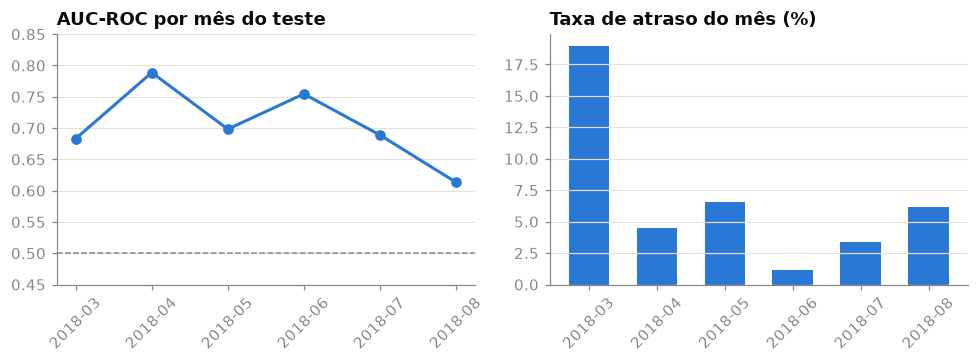

,pedidos,taxa_atraso,auc_roc,auc_pr
mês,,,,
2018-03,7003,0.1896,0.6831,0.3360
2018-04,6798,0.0450,0.7887,0.1476
2018-05,6749,0.0656,0.6983,0.1292
2018-06,6096,0.0116,0.7545,0.0360
2018-07,6156,0.0338,0.6889,0.0759
2018-08,6351,0.0619,0.6134,0.0841


In [12]:
proba_test = finalists[CHAMPION].predict_proba(X_test)[:, 1]
monthly = monthly_stratification(test, proba_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
x = range(len(monthly))
ax1.plot(x, monthly["auc_roc"], color=ACCENT, linewidth=2, marker="o")
ax1.axhline(0.5, color=GRAY, linewidth=1, linestyle="--")
ax1.set_xticks(x, monthly.index, rotation=45)
ax1.set_title("AUC-ROC por mês do teste")
ax1.set_ylim(0.45, 0.85)
ax2.bar(x, 100 * monthly["taxa_atraso"], color=ACCENT, width=0.6)
ax2.set_xticks(x, monthly.index, rotation=45)
ax2.set_title("Taxa de atraso do mês (%)")
plt.tight_layout()
plt.show()

monthly.round(4)

**Leitura:** a capacidade de ORDENAÇÃO se mantém em todos os regimes (AUC-ROC entre 0,61 e 0,79, sempre acima do acaso), inclusive no mês da greve (0,698 em maio) e no mês recalibrado (0,755 em junho, quando a taxa despencou a 1,2%). O pior mês é agosto (0,613), o mais distante do treino, o desenho clássico de drift: desempenho decai com a distância temporal do treino, e é este gráfico que vira o argumento de monitoramento e gatilho de retreino em produção. A AUC-PR mensal acompanha a prevalência (0,336 em março com taxa 19%; 0,036 em junho com taxa 1,2%), como a teoria manda, e por isso ela não se compara entre meses.

## 9. O menu de operação e o cenário de negócio em contagens

A curva precision-recall da campeã na validação, com os três pontos nomeados. Cada ponto vira, no teste, um cenário operacional em CONTAGENS por mês típico (~6.526 pedidos): clientes notificados, atrasos capturados, falsos alarmes. Nenhum número monetário assumido: a decisão de custo pertence ao negócio, e o app da etapa 6 recalcula este cenário ao vivo com um slider.

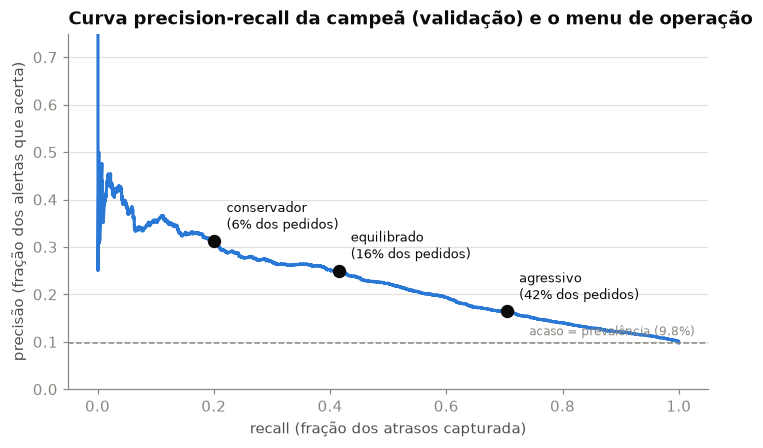

In [13]:
proba_val_champ = core_fitted[CHAMPION].predict_proba(X_val)[:, 1]
prec, rec, _ = precision_recall_curve(y_val, proba_val_champ)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(rec, prec, color=ACCENT, linewidth=2)
ax.axhline(y_val.mean(), color=GRAY, linewidth=1, linestyle="--")
ax.annotate(
    f"acaso = prevalência ({y_val.mean():.1%})",
    xy=(0.98, y_val.mean()), xycoords=("axes fraction", "data"),
    xytext=(0, 5), textcoords="offset points", ha="right", fontsize=8, color=GRAY,
)
for name, row in ops.iterrows():
    ax.scatter(row["recall_val"], row["precisão_val"], s=60, color=INK, zorder=3)
    ax.annotate(
        f"{name}\n({row['alert_rate_val']:.0%} dos pedidos)",
        xy=(row["recall_val"], row["precisão_val"]),
        xytext=(8, 8), textcoords="offset points", fontsize=8.5, color=INK,
    )
ax.set_title("Curva precision-recall da campeã (validação) e o menu de operação")
ax.set_xlabel("recall (fração dos atrasos capturada)")
ax.set_ylabel("precisão (fração dos alertas que acerta)")
ax.set_ylim(0, 0.75)
plt.show()

In [14]:
menu = []
for name, row in ops.iterrows():
    rate = float(row["alert_rate_val"])
    thr_test = threshold_for_alert_rate(proba_test, rate)
    scenario = business_scenario(y_test, proba_test, thr_test, n_months=6)
    month = scenario.loc["por mês típico"]
    menu.append(
        {
            "ponto": name,
            "orçamento de alertas": f"{rate:.1%}",
            "notificados/mês": int(month.iloc[0]),
            "atrasos capturados/mês": int(month.iloc[1]),
            "falsos alarmes/mês": int(month.iloc[2]),
            "% dos atrasos capturados": scenario.iloc[0, 4],
            "precisão no teste": f"{month.iloc[1] / month.iloc[0]:.1%}",
        }
    )
pd.DataFrame(menu).set_index("ponto")

,orçamento de alertas,notificados/mês,atrasos capturados/mês,falsos alarmes/mês,% dos atrasos capturados,precisão no teste
ponto,,,,,,
conservador,6.3%,409,74,335,16%,18.1%
equilibrado,16.2%,1054,166,888,36%,15.7%
agressivo,41.8%,2729,314,2415,68%,11.5%


In [15]:
DEFAULT_RATE = float(ops.loc["equilibrado", "alert_rate_val"])
business_scenario(
    y_test, proba_test, threshold_for_alert_rate(proba_test, DEFAULT_RATE), n_months=6
)

,clientes notificados,atrasos capturados,falsos alarmes,atrasos não capturados,% dos atrasos capturados
teste completo (6 meses),6326,996,5330,1753,36%
por mês típico,1054,166,888,292,36%


**Leitura de negócio, no ponto equilibrado (default):** notificando ~1.054 clientes por mês (16% do volume), a operação captura ~166 dos ~464 atrasos mensais (36%), ao custo de ~888 falsos alarmes. A precisão de 15,7% deve ser lida contra a base: um sorteio aleatório de clientes para notificar acertaria 7%; o modelo acerta 2,2x mais por alerta. O menu dá os extremos: com orçamento enxuto de 6% notificam-se 409 e cada alerta acerta 18% (2,6x o acaso); com orçamento largo de 42% capturam-se 68% dos atrasos. **A escolha entre os pontos é uma decisão de custo operacional, não de estatística, e é exatamente essa decisão que o slider do app entrega ao gestor.**

## 10. O que o modelo usa: coeficientes e importância por permutação

Campeã linear tem interpretabilidade nativa: cada coeficiente padronizado lê-se como o efeito de um desvio-padrão da variável (ou da presença da categoria) sobre o risco. Complemento agnóstico: a importância por permutação (embaralhar uma feature e medir quanto a AUC-PR cai na validação, com o modelo do núcleo, fora da amostra).

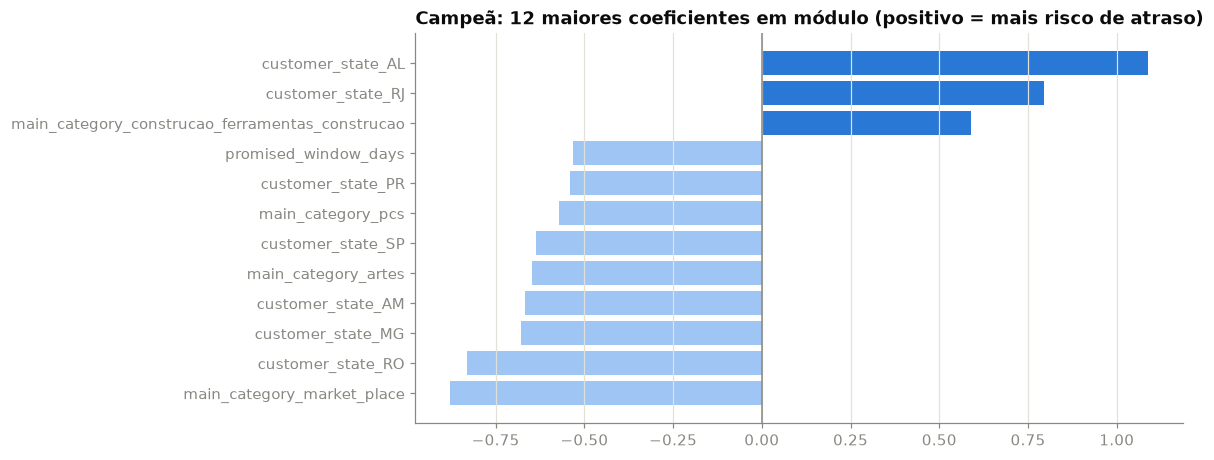

In [16]:
prep = finalists[CHAMPION].named_steps["prep"]
coef = pd.DataFrame(
    {
        "feature": [n.split("__", 1)[1] for n in prep.get_feature_names_out()],
        "coef": finalists[CHAMPION].named_steps["model"].coef_[0],
    }
)
top = coef.reindex(coef["coef"].abs().sort_values(ascending=False).index).head(12)
top = top.sort_values("coef")

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(top["feature"], top["coef"], color=[ACCENT if c > 0 else "#9ec5f4" for c in top["coef"]])
ax.axvline(0, color=GRAY, linewidth=1)
ax.grid(axis="x", color="#e1e0d9")
ax.grid(axis="y", visible=False)
ax.set_title("Campeã: 12 maiores coeficientes em módulo (positivo = mais risco de atraso)")
plt.show()

In [17]:
pi = permutation_importance(
    core_fitted[CHAMPION], X_val, y_val,
    scoring="average_precision", n_repeats=5, random_state=42, n_jobs=-1,
)
pd.DataFrame({"feature": FEATURES, "queda_auc_pr": pi.importances_mean}).sort_values(
    "queda_auc_pr", ascending=False
).head(10).round(4).reset_index(drop=True)

,feature,queda_auc_pr
0,customer_state,0.0987
1,promised_window_days,0.0561
2,distance_km,0.0293
3,seller_posting_days_hist,0.0247
4,purchase_month,0.0091
5,main_category,0.0050
6,total_weight_g,0.0047
7,n_sellers,0.0038
8,payment_type_primary,0.0028
9,distance_missing,0.0015


**Leitura das importâncias, com as honestidades devidas:**

1. **Geografia domina**, como a EDA previu: a UF de destino é a feature mais importante (queda de 0,099 na AUC-PR quando embaralhada), com AL e RJ puxando risco para cima nos coeficientes e SP/MG/PR para baixo.
2. **A janela prometida é a 2ª força** (queda 0,056), com coeficiente NEGATIVO (janelas longas protegem), coerente com o achado não monotônico da EDA na parte que a estrutura linear consegue capturar.
3. **Distância em 3º** (queda 0,029), o gradiente físico confirmado de ponta a ponta do projeto.
4. **Das duas features herméticas do vendedor, o tempo de postagem histórico é a que importa** (4ª, queda 0,025); a taxa de atraso histórica ficou modesta. Honestidade registrada: a feature tecnicamente mais sofisticada do projeto NÃO é a mais importante, e tudo bem, o rigor da construção não era pelo ganho de métrica, era para que ganho nenhum fosse ilusório. O sintoma precoce (postagem lenta) vale mais que o histórico do desfecho raro, o que faz sentido físico: postagem lenta é observada em TODO pedido do vendedor, atraso só nos ~7%.

## 11. Conclusões finais do notebook

1. **Contrato anti-vazamento cumprido de ponta a ponta:** auditoria de colunas → features herméticas testadas por pytest → estatísticas só de treino → alvo embaralhado em 0,500.
2. **Campeã: Regressão Logística C=0,1** (selecionada na validação), AUC-PR 0,138 no teste (2,0x o acaso), AUC-ROC 0,699, ordenação estável através de crise, greve e recalibração (0,61–0,79 por mês).
3. **Achado de seleção documentado:** o LightGBM venceu no teste (0,181; 2,6x o acaso); a troca não foi feita por disciplina de protocolo, e a lição vira próximo passo: validação em múltiplas janelas (rolling origin) antes de produção.
4. **Ponto de operação como orçamento de alertas** (transferível entre retreinos): default equilibrado = 16% dos pedidos, capturando 36% dos atrasos com precisão 2,2x o acaso; menu completo de 6% a 42% para a decisão do negócio.
5. **Drift visível e narrado:** agosto (mês mais distante do treino) é o pior mês em ordenação, o argumento empírico para monitoramento e gatilho de retreino em produção.
6. **Próximos artefatos (etapas 6 e 7):** app Streamlit com o cenário recalculado ao vivo, relatório executivo, README com a arquitetura de produção.